<a href="https://colab.research.google.com/github/Vineesha2005/HPC-Project/blob/main/Hpc_Project(1873).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from collections import Counter
import time

# Load dataset
df = pd.read_excel("log_dataset (1).xlsx")

# Combine all text
text = " ".join(df.astype(str).values.flatten())

# Word count function
def count_words(text):
    words = text.split()
    return Counter(words)

# Sequential execution
start = time.time()
result = count_words(text)
end = time.time()

print("Sequential Time:", end - start)
print("Top Words:", result.most_common(5))

Sequential Time: 0.06996369361877441
Top Words: [('2026-04-06', 50000), ('to', 14820), ('INFO', 12625), ('WARNING', 12478), ('DEBUG', 12453)]


In [9]:
import pandas as pd
import multiprocessing
from collections import Counter
import time

# Function to count words
def count_words(text):
    words = text.split()
    return Counter(words)

# Parallel function
def parallel_count(chunks):
    with multiprocessing.Pool() as pool:
        results = pool.map(count_words, chunks)

        final = Counter()
        for r in results:
            final.update(r)

        return final


if __name__ == "__main__":

    # 🔹 Load Excel dataset
    df = pd.read_excel("log_dataset (1).xlsx")

    # 🔹 Convert each row into a string (IMPORTANT)
    chunks = list(df.astype(str).apply(lambda row: " ".join(row), axis=1))

    # 🔹 Parallel Execution
    start = time.time()
    result = parallel_count(chunks)
    end = time.time()

    print("Parallel Time:", end - start)
    print("Top Words:", result.most_common(5))

Parallel Time: 1.0076875686645508
Top Words: [('2026-04-06', 50000), ('to', 14820), ('INFO', 12625), ('WARNING', 12478), ('DEBUG', 12453)]


Sequential Time: 0.06720852851867676
Parallel Time: 0.14423823356628418


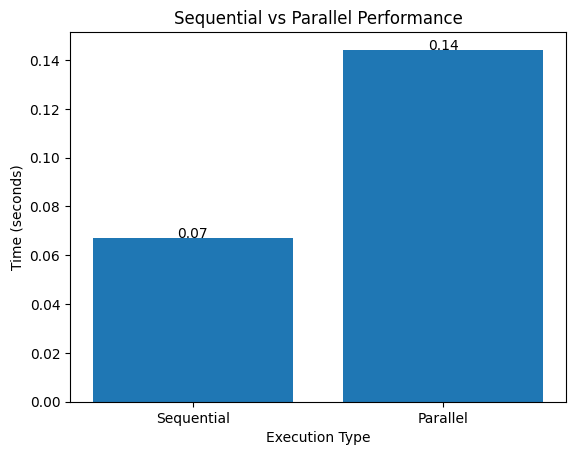

In [11]:
import pandas as pd
import multiprocessing
from collections import Counter
import time
import matplotlib.pyplot as plt

def count_words(text):
    words = text.split()
    return Counter(words)

def parallel_count(chunks):
    with multiprocessing.Pool() as pool:
        results = pool.map(count_words, chunks)

        final = Counter()
        for r in results:
            final.update(r)

        return final


if __name__ == "__main__":

    df = pd.read_excel("log_dataset (1).xlsx")
    text = " ".join(df.astype(str).values.flatten())

    # ▓ Sequential
    start = time.time()
    count_words(text)
    seq_time = time.time() - start

    # ▓ Parallel
    # Note: Using text.split("\n") for chunks might not be optimal for word counting if lines are not natural divisions.
    # A better approach for this specific problem might involve splitting the entire text into smaller word-based chunks.
    chunks = text.split("\n") # This assumes each line is a logical chunk for parallel processing.
    start = time.time()
    parallel_count(chunks)
    par_time = time.time() - start

    print("Sequential Time:", seq_time)
    print("Parallel Time:", par_time)

    # ▓ Graph
    labels = ["Sequential", "Parallel"]
    times = [seq_time, par_time]

    plt.figure()
    plt.bar(labels, times)
    plt.xlabel("Execution Type")
    plt.ylabel("Time (seconds)")
    plt.title("Sequential vs Parallel Performance")

    for i in range(len(times)):
        plt.text(i, times[i], f"{times[i]:.2f}", ha='center')

    plt.savefig("comparison.png")
    plt.show()